In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.base import clone

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

RANDOM_STATE = 42


In [11]:
df = pd.read_csv("Ukraine_commercial_ML.csv")

In [12]:
CAT_PREFIX = "city_"
CAT_COL = "city_raw"
CAT_MASTER_LIST = ['Lviv', 'Kharkiv', 'Dnipro', 'Zaporizhzhia', 'Odesa', 'Poltava', 'Mykolaiv', 'Cherkasy', 'Kropyvnytskyi', 'Sumy', 'Chernihiv', 'Zhytomyr', 'Lutsk', 'Ivano-Frankivsk', 'Ternopil', 'Khmelnytskyi', 'Uzhhorod', 'Vinnytsia', 'Rivne', 'Chernivtsi', 'Kherson']


def reconstruct_categorical(df: pd.DataFrame, prefix: str, master_list: list[str]) -> tuple[pd.Series, list[str]]:
    dummy_cols = [c for c in df.columns if c.startswith(prefix)]
    present = {c[len(prefix):] for c in dummy_cols}
    # базова категорія — найменша за абеткою з майстер-списку, якої
    # немає серед dummy-колонок (навіть якщо є ще й інші відсутні —
    # ті просто мають 0 рядків у цьому датасеті й ніколи не будуть обрані)
    missing_sorted = sorted(m for m in master_list if m not in present)
    reference = missing_sorted[0]

    cat = pd.Series(reference, index=df.index, dtype="object")
    for c in dummy_cols:
        name = c[len(prefix):]
        cat = cat.where(~df[c].astype(bool), name)
    return cat, dummy_cols


df[CAT_COL], _dummy_cols = reconstruct_categorical(df, CAT_PREFIX, CAT_MASTER_LIST)
df = df.drop(columns=_dummy_cols)
print(df[CAT_COL].value_counts())

city_raw
Lviv               397
Odesa              273
Ivano-Frankivsk    267
Dnipro             111
Kharkiv             84
Khmelnytskyi        71
Chernihiv           32
Zaporizhzhia        27
Chernivtsi          24
Vinnytsia           24
Poltava             19
Zhytomyr            17
Cherkasy            14
Uzhhorod            14
Sumy                11
Ternopil            11
Rivne                7
Kropyvnytskyi        5
Lutsk                5
Mykolaiv             4
Name: count, dtype: int64


In [13]:
is_other = (df["is_garage"] | df["is_parking_spot"] | df["is_warehouse"]).astype(bool)
df_premises = df[~is_other].reset_index(drop=True)
df_other = df[is_other].reset_index(drop=True)

print("Приміщення:", df_premises.shape)
print("Гараж/паркомісце/склад:", df_other.shape)

Приміщення: (462, 51)
Гараж/паркомісце/склад: (955, 51)


In [14]:
TARGET = "price"
MISSING_COLS = ["ceiling_height", "year_of_building", "poi_distance_m", "rental_price", "implied_yield", "floor_count"]


def build_feature_frames(df: pd.DataFrame):
    """Ціль — price_per_sqm = price/area. 'price' і сира категоріальна
    колонка CAT_COL виключені з X (CAT_COL кодується окремо, per-split,
    через target encoding — щоб не було витоку). Повертає
    (X_raw, X_imputed, y, cat_raw)."""
    price_per_sqm = df[TARGET] / df["area"]

    feature_cols = [c for c in df.columns if c not in (TARGET, CAT_COL)]
    X_raw = df[feature_cols].astype({c: "float64" for c in df[feature_cols].select_dtypes("bool").columns})

    X_imputed = X_raw.copy()
    for col in MISSING_COLS:
        if col in X_imputed.columns:
            flag_col = f"{col}_missing"
            X_imputed[flag_col] = X_imputed[col].isna().astype(int)
            X_raw[flag_col] = X_imputed[flag_col]
            median_val = X_imputed[col].median()
            X_imputed[col] = X_imputed[col].fillna(median_val)

    y = np.log1p(price_per_sqm)
    return X_raw, X_imputed, y, df[CAT_COL]

In [15]:
def fit_target_encoding(cat_train: pd.Series, y_train: pd.Series, m: float = 10.0):
    global_mean = float(y_train.mean())
    stats = y_train.groupby(cat_train).agg(["mean", "count"])
    mapping = (stats["count"] * stats["mean"] + m * global_mean) / (stats["count"] + m)
    return mapping, global_mean


def apply_target_encoding(cat: pd.Series, mapping: pd.Series, global_mean: float) -> pd.Series:
    return cat.map(mapping).fillna(global_mean)

In [16]:
def drop_constant_columns(X: pd.DataFrame) -> pd.DataFrame:
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if constant_cols:
        print(f"  Прибрано {len(constant_cols)} константних колонок: {constant_cols}")
    return X.drop(columns=constant_cols)


def prune_by_vif(X: pd.DataFrame, thresh: float = 10.0) -> list[str]:
    X = drop_constant_columns(X).astype(float)
    X_const = add_constant(X, has_constant="add")

    while X_const.shape[1] > 2:
        vifs = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns,
        ).drop("const")
        worst = vifs.idxmax()
        if vifs[worst] < thresh:
            break
        print(f"  Дропаю '{worst}' (VIF={vifs[worst]:.1f})")
        X_const = X_const.drop(columns=[worst])

    kept = [c for c in X_const.columns if c != "const"]
    print(f"  Лишилось {len(kept)} ознак після VIF-відбору")
    return kept


def evaluate(y_true_log: np.ndarray, y_pred_log: np.ndarray, area: np.ndarray) -> dict:
    """Модель оптимізується на log(price_per_sqm); поруч із метриками
    на $/м² рахуємо ще й відновлену $ (price_per_sqm_pred * area) —
    кінцевого стейкхолдера цікавить саме загальна ціна об'єкта."""
    ppsqm_true = np.expm1(y_true_log)
    ppsqm_pred = np.expm1(y_pred_log)
    price_true = ppsqm_true * area
    price_pred = ppsqm_pred * area
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "MAPE_%_per_sqm": (np.abs((ppsqm_true - ppsqm_pred) / ppsqm_true).mean()) * 100,
        "MAE_$_total": mean_absolute_error(price_true, price_pred),
        "RMSE_$_total": mean_squared_error(price_true, price_pred) ** 0.5,
        "MAPE_%_total": (np.abs((price_true - price_pred) / price_true).mean()) * 100,
    }


RF_GRID = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 12, 20],
    "min_samples_leaf": [1, 2, 4],
}
HGB_GRID = {
    "max_iter": [200, 400, 600],
    "max_depth": [None, 4, 8],
    "learning_rate": [0.03, 0.06, 0.1],
}


def fit_variant(model_name, Xr_train, Xr_test, Xi_train, Xi_test, y_train, y_test, area_test, cols, fixed_params=None):
    """Навчає одну з трьох моделей на заданому підмножині колонок `cols`.
    Якщо fixed_params задано — не робить GridSearchCV, а просто ставить ці
    гіперпараметри (використовується у крос-валідації нижче, де
    перетюнювати на кожному фолді занадто дорого)."""
    Xr_train_c, Xr_test_c = Xr_train[cols], Xr_test[cols]
    Xi_train_c, Xi_test_c = Xi_train[cols], Xi_test[cols]

    if model_name == "Ridge":
        scaler = StandardScaler()
        Xs_train_c = scaler.fit_transform(Xi_train_c)
        Xs_test_c = scaler.transform(Xi_test_c)
        if fixed_params is not None:
            model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(Xs_train_c, y_train)
        else:
            model = RidgeCV(alphas=np.logspace(-2, 3, 30)).fit(Xs_train_c, y_train)
        X_test_final = Xs_test_c

    elif model_name == "RandomForest":
        if fixed_params is not None:
            model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xi_train_c, y_train)
        else:
            search = GridSearchCV(
                RandomForestRegressor(random_state=RANDOM_STATE),
                RF_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(Xi_train_c, y_train)
            model = search.best_estimator_
        X_test_final = Xi_test_c

    else:  # HistGradientBoosting — працює напряму з NaN
        if fixed_params is not None:
            model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xr_train_c, y_train)
        else:
            search = GridSearchCV(
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                HGB_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(Xr_train_c, y_train)
            model = search.best_estimator_
        X_test_final = Xr_test_c

    metrics = evaluate(y_test.values, model.predict(X_test_final), area_test.values)
    return model, X_test_final, metrics


def get_model_params(model_name: str, model) -> dict:
    """Гіперпараметри переможця — щоб зафіксувати їх для крос-валідації
    (там ми не перетюнюємо на кожному фолді, це занадто дорого)."""
    if model_name == "Ridge":
        return {"alpha_": model.alpha_}
    if model_name == "RandomForest":
        return {k: v for k, v in model.get_params().items()
                if k in ("n_estimators", "max_depth", "min_samples_leaf")}
    return {k: v for k, v in model.get_params().items()
            if k in ("max_iter", "max_depth", "learning_rate")}

In [17]:
def train_and_compare(df_segment: pd.DataFrame, segment_name: str, vif_thresh: float = 10.0):
    print(f"\n{'='*60}\n{segment_name}\n{'='*60}")

    X_raw, X_imputed, y, cat_raw = build_feature_frames(df_segment)
    idx_train, idx_test = train_test_split(
        df_segment.index, test_size=0.2, random_state=RANDOM_STATE
    )

    Xr_train, Xr_test = X_raw.loc[idx_train].copy(), X_raw.loc[idx_test].copy()
    Xi_train, Xi_test = X_imputed.loc[idx_train].copy(), X_imputed.loc[idx_test].copy()
    y_train, y_test = y.loc[idx_train], y.loc[idx_test]
    area_test = df_segment.loc[idx_test, "area"]

    # target encoding — mapping рахується ЛИШЕ на train
    te_mapping, te_global_mean = fit_target_encoding(cat_raw.loc[idx_train], y_train)
    enc_col = f"{CAT_COL}_target_enc"
    for X in (Xr_train, Xi_train):
        X[enc_col] = apply_target_encoding(cat_raw.loc[idx_train], te_mapping, te_global_mean).values
    for X in (Xr_test, Xi_test):
        X[enc_col] = apply_target_encoding(cat_raw.loc[idx_test], te_mapping, te_global_mean).values

    full_cols = list(X_imputed.columns) + [enc_col]

    print("--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---")
    results, fitted = {}, {}
    for name in ["Ridge", "RandomForest", "HistGradientBoosting"]:
        model, X_test_final, metrics = fit_variant(
            name, Xr_train, Xr_test, Xi_train, Xi_test, y_train, y_test, area_test, full_cols
        )
        results[name] = metrics
        fitted[name] = model

    results_df = pd.DataFrame(results).T
    print("\n--- Результати на test (повний набір ознак) ---")
    print(results_df)

    best_name = results_df["R2"].idxmax()
    print(f"\n>>> Найкраща модель: {best_name}")

    print("\n--- VIF-відбір (лише для feature importance, на train) ---")
    kept_cols = prune_by_vif(Xi_train, thresh=vif_thresh)

    best_model_pruned, X_test_pruned, pruned_metrics = fit_variant(
        best_name, Xr_train, Xr_test, Xi_train, Xi_test, y_train, y_test, area_test, kept_cols
    )
    print(f"\nR² {best_name}: повний набір ознак = {results_df.loc[best_name, 'R2']:.3f}, "
          f"після VIF-відбору = {pruned_metrics['R2']:.3f}")
    print(f"MAPE_%_total ($ на весь об'єкт) після VIF-відбору: {pruned_metrics['MAPE_%_total']:.1f}%")

    perm = permutation_importance(
        best_model_pruned, X_test_pruned, y_test, n_repeats=20,
        random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
    )
    importance_df = (
        pd.DataFrame({"feature": kept_cols, "importance": perm.importances_mean,
                      "std": perm.importances_std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    top_n = importance_df.head(15)
    plt.figure(figsize=(8, 6))
    plt.barh(top_n["feature"][::-1], top_n["importance"][::-1], xerr=top_n["std"][::-1])
    plt.xlabel("Permutation importance (спад R² при перемішуванні ознаки)")
    plt.title(f"{segment_name} — {best_name} (після VIF) — топ ознак, ціль = $/м²")
    plt.tight_layout()
    plt.show()

    return {
        "results_df": results_df,
        "best_name": best_name,
        "best_model_pruned": best_model_pruned,
        "fixed_params": get_model_params(best_name, best_model_pruned),
        "importance_df": importance_df,
        "kept_cols": kept_cols,
        "enc_col": enc_col,
    }

In [18]:
def cross_validate_best(df_segment: pd.DataFrame, best_name: str, kept_cols: list[str],
                         fixed_params: dict, enc_col: str, n_splits: int = 5):
    X_raw, X_imputed, y, cat_raw = build_feature_frames(df_segment)
    area_all = df_segment["area"]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []

    for fold_i, (tr_idx, val_idx) in enumerate(kf.split(df_segment.index), start=1):
        idx_tr = df_segment.index[tr_idx]
        idx_val = df_segment.index[val_idx]

        Xr_tr, Xr_val = X_raw.loc[idx_tr].copy(), X_raw.loc[idx_val].copy()
        Xi_tr, Xi_val = X_imputed.loc[idx_tr].copy(), X_imputed.loc[idx_val].copy()
        y_tr, y_val = y.loc[idx_tr], y.loc[idx_val]
        area_val = area_all.loc[idx_val]

        te_mapping, te_global_mean = fit_target_encoding(cat_raw.loc[idx_tr], y_tr)
        for X in (Xr_tr, Xi_tr):
            X[enc_col] = apply_target_encoding(cat_raw.loc[idx_tr], te_mapping, te_global_mean).values
        for X in (Xr_val, Xi_val):
            X[enc_col] = apply_target_encoding(cat_raw.loc[idx_val], te_mapping, te_global_mean).values

        cols = [c for c in kept_cols if c in Xi_tr.columns]
        _, _, metrics = fit_variant(
            best_name, Xr_tr, Xr_val, Xi_tr, Xi_val, y_tr, y_val, area_val, cols, fixed_params=fixed_params
        )
        metrics["fold"] = fold_i
        fold_metrics.append(metrics)

    cv_df = pd.DataFrame(fold_metrics).set_index("fold")
    summary = cv_df.agg(["mean", "std"])
    print(cv_df)
    print("\n--- Підсумок по фолдах ---")
    print(summary)
    return cv_df

In [19]:
def save_production_pipeline(df_segment: pd.DataFrame, best_name: str, kept_cols: list[str],
                             fixed_params: dict, enc_col: str, out_file: str):
    X_raw, X_imputed, y, cat_raw = build_feature_frames(df_segment)
    area_all = df_segment["area"]

    te_mapping, te_global_mean = fit_target_encoding(cat_raw, y)
    for X in (X_raw, X_imputed):
        X[enc_col] = apply_target_encoding(cat_raw, te_mapping, te_global_mean).values

    cols = [c for c in kept_cols if c in X_imputed.columns]
    Xi_c = X_imputed[cols]
    Xr_c = X_raw[cols]

    scaler = None
    if best_name == "Ridge":
        scaler = StandardScaler().fit(Xi_c)
        model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(scaler.transform(Xi_c), y)
    elif best_name == "RandomForest":
        model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xi_c, y)
    else:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xr_c, y)

    median_fill = {col: X_imputed[col].median() for col in MISSING_COLS if col in X_imputed.columns}

    artifact = {
        "model_name": best_name,
        "model": model,
        "scaler": scaler,
        "feature_cols": cols,
        "cat_col": CAT_COL,
        "cat_prefix": CAT_PREFIX,
        "target_encoding_mapping": te_mapping,
        "target_encoding_global_mean": te_global_mean,
        "target_enc_col": enc_col,
        "missing_cols": MISSING_COLS,
        "median_fill": median_fill,
    }
    joblib.dump(artifact, out_file)
    print(f"Збережено: {out_file}")
    return artifact


def predict_new_object(artifact: dict, new_row: dict) -> float:
    """new_row — звичайний dict з сирими значеннями ознак (як у вихідному
    df ДО one-hot/target encoding), включно з CAT_COL (напр. 'city_raw') і
    'area'. Повертає прогнозовану ЗАГАЛЬНУ ціну об'єкта в $."""
    row = pd.Series(new_row)

    cat_value = row.get(artifact["cat_col"], None)
    mapping = artifact["target_encoding_mapping"]
    row[artifact["target_enc_col"]] = (
        mapping.get(cat_value, artifact["target_encoding_global_mean"])
        if cat_value in mapping.index else artifact["target_encoding_global_mean"]
    )

    for col in artifact["missing_cols"]:
        if col in artifact["feature_cols"] and (col not in row or pd.isna(row.get(col))):
            row[col] = artifact["median_fill"].get(col, 0)
        flag_col = f"{col}_missing"
        if flag_col in artifact["feature_cols"]:
            row[flag_col] = int(col not in new_row or pd.isna(new_row.get(col)))

    X_new = pd.DataFrame([row])[artifact["feature_cols"]].astype(float)
    if artifact["scaler"] is not None:
        X_new = artifact["scaler"].transform(X_new)

    pred_log_ppsqm = artifact["model"].predict(X_new)[0]
    pred_ppsqm = np.expm1(pred_log_ppsqm)
    return pred_ppsqm * new_row["area"]


Приміщення (Україна)
--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---

--- Результати на test (повний набір ознак) ---
                            R2  MAPE_%_per_sqm   MAE_$_total  RMSE_$_total  \
Ridge                 0.281371       59.787271  33980.273996  51707.308147   
RandomForest          0.231801       63.310924  35674.078703  51574.045927   
HistGradientBoosting  0.234602       62.447078  38714.374980  53786.953566   

                      MAPE_%_total  
Ridge                    59.787271  
RandomForest             63.310924  
HistGradientBoosting     62.447078  

>>> Найкраща модель: Ridge

--- VIF-відбір (лише для feature importance, на train) ---
  Прибрано 8 константних колонок: ['is_warehouse', 'is_garage', 'is_parking_spot', 'is_exclusive', 'house_type_belgian_project', 'house_type_hostinka', 'ceiling_height_missing', 'year_of_building_missing']
  Дропаю 'has_poi' (VIF=inf)
  Дропаю 'house_type_austrian_lux' (VIF=inf)
  Дропаю 'wall_type_block' (VIF=inf)
  Дропаю 'he

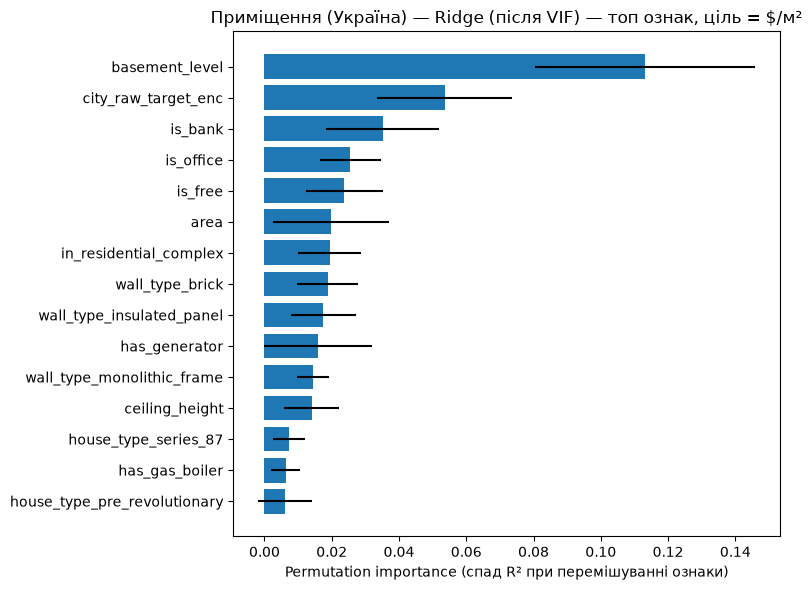

In [20]:
premises_result = train_and_compare(df_premises, "Приміщення (Україна)")

In [21]:
premises_result["importance_df"].head(15)

,feature,importance,std
0,basement_level,0.113209,0.032673
1,city_raw_target_enc,0.053554,0.020009
2,is_bank,0.035201,0.016812
3,is_office,0.025485,0.009079
4,is_free,0.023743,0.011399
5,area,0.019690,0.017266
6,in_residential_complex,0.019380,0.009276
7,wall_type_brick,0.018776,0.009117
8,wall_type_insulated_panel,0.017527,0.009587
9,has_generator,0.015839,0.016011


In [22]:
premises_cv = cross_validate_best(
    df_premises, premises_result["best_name"], premises_result["kept_cols"],
    premises_result["fixed_params"], premises_result["enc_col"],
)

            R2  MAPE_%_per_sqm   MAE_$_total  RMSE_$_total  MAPE_%_total
fold                                                                    
1     0.284474       59.640811  33585.522794  51199.927376     59.640811
2     0.049265      105.735451  45669.194545  61025.623785    105.735451
3     0.200847       46.012574  51716.063861  75946.231383     46.012574
4    -3.747965      154.178887  41434.512972  58140.669048    154.178887
5     0.283002       34.446566  40903.107303  58522.946837     34.446566

--- Підсумок по фолдах ---
            R2  MAPE_%_per_sqm   MAE_$_total  RMSE_$_total  MAPE_%_total
mean -0.586075       80.002858  42661.680295  60967.079686     80.002858
std   1.770141       49.521656   6670.872456   9134.249554     49.521656


In [23]:
premises_artifact = save_production_pipeline(
    df_premises, premises_result["best_name"], premises_result["kept_cols"],
    premises_result["fixed_params"], premises_result["enc_col"],
    out_file="premises_model_pipeline.joblib",
)

Збережено: premises_model_pipeline.joblib



Гараж / паркомісце / склад (Україна)
--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---

--- Результати на test (повний набір ознак) ---
                            R2  MAPE_%_per_sqm   MAE_$_total  RMSE_$_total  \
Ridge                 0.419603      108.034410  43299.212525  74704.037662   
RandomForest          0.364867      113.462422  50128.403388  92451.657135   
HistGradientBoosting  0.383941      106.550596  50004.495794  91439.672329   

                      MAPE_%_total  
Ridge                   108.034410  
RandomForest            113.462422  
HistGradientBoosting    106.550596  

>>> Найкраща модель: Ridge

--- VIF-відбір (лише для feature importance, на train) ---
  Прибрано 1 константних колонок: ['house_type_series_96']
  Дропаю 'is_warehouse' (VIF=inf)
  Дропаю 'rental_price' (VIF=inf)
  Дропаю 'has_poi' (VIF=inf)
  Дропаю 'rental_price_missing' (VIF=inf)
  Дропаю 'ceiling_height_missing' (VIF=20.3)
  Лишилось 50 ознак після VIF-відбору

R² Ridge: повний набір ознак = 

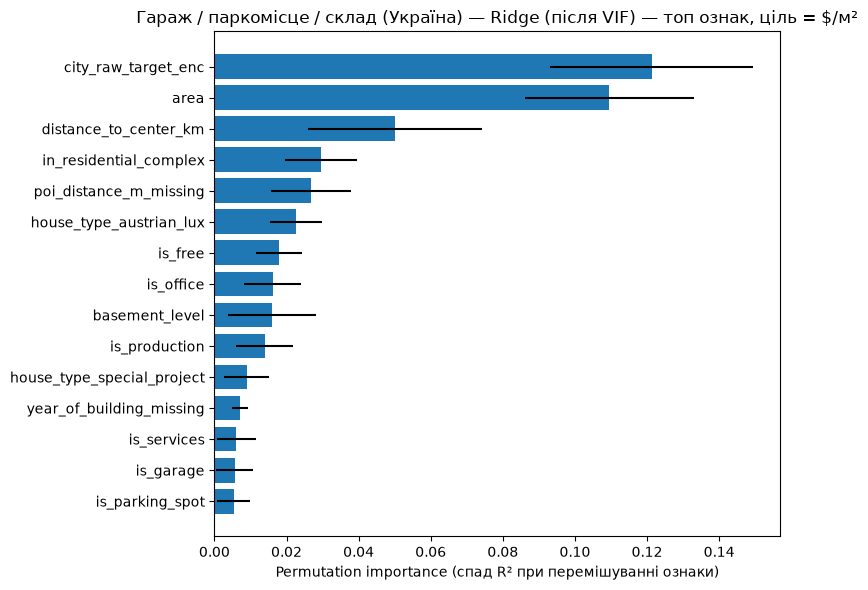

In [24]:
other_result = train_and_compare(df_other, "Гараж / паркомісце / склад (Україна)")

In [25]:
other_result["importance_df"].head(15)

,feature,importance,std
0,city_raw_target_enc,0.121303,0.028105
1,area,0.109566,0.023506
2,distance_to_center_km,0.050024,0.024064
3,in_residential_complex,0.029648,0.009949
4,poi_distance_m_missing,0.026878,0.011068
5,house_type_austrian_lux,0.022595,0.007177
6,is_free,0.017854,0.006439
7,is_office,0.016156,0.007876
8,basement_level,0.015935,0.012284
9,is_production,0.013950,0.007882


In [26]:
other_cv = cross_validate_best(
    df_other, other_result["best_name"], other_result["kept_cols"],
    other_result["fixed_params"], other_result["enc_col"],
)

            R2  MAPE_%_per_sqm   MAE_$_total  RMSE_$_total  MAPE_%_total
fold                                                                    
1     0.420829      108.490283  43296.431663  74715.454579    108.490283
2     0.522616       67.490414  48983.510352  89614.647877     67.490414
3     0.568168       48.198843  40395.944508  71639.563913     48.198843
4     0.541229       43.689159  39389.595040  72980.680985     43.689159
5     0.611565       46.038652  37992.953485  69378.562640     46.038652

--- Підсумок по фолдах ---
            R2  MAPE_%_per_sqm   MAE_$_total  RMSE_$_total  MAPE_%_total
mean  0.532881       62.781470  42011.687010  75665.781999     62.781470
std   0.071005       27.244087   4355.832263   8037.775007     27.244087


In [27]:
other_artifact = save_production_pipeline(
    df_other, other_result["best_name"], other_result["kept_cols"],
    other_result["fixed_params"], other_result["enc_col"],
    out_file="other_model_pipeline.joblib",
)

Збережено: other_model_pipeline.joblib
